In [5]:
import json
import os
import tol_colors as tc
cset = tc.tol_cset('muted')
color_avian = cset[0]
color_cattle = cset[1]

b313_hyphy_dir = '../analysis/b313/hyphy/B.3.13_RELAX_FUBAR/'
hyphy_results = {seg: {} for seg in ['PB2', 'PB1', 'NP', 'NS', 'PA_HA_NA_MP']}

# save RELAX alternative model data for all segments
for d in os.listdir(b313_hyphy_dir):
    if not d.startswith('_'):
        continue
    seg = d.strip('_')
    for f in os.listdir(os.path.join(b313_hyphy_dir, d)):
        if f.endswith('rateSyn.json'):
            with open(os.path.join(b313_hyphy_dir, d, f)) as jf:
                data = json.load(jf)
            hyphy_results[seg][f.split('.')[-2]] = {}
            hyphy_results[seg][f.split('.')[-2]]['parameters'] = data['fits']['RELAX alternative']
            hyphy_results[seg][f.split('.')[-2]]['test results'] = data['test results']
            hyphy_results[seg][f.split('.')[-2]]['omega'] = data['fits']["MG94xREV with separate rates for branch sets"]["Rate Distributions"]
            


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_41954/43856774.py:4: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


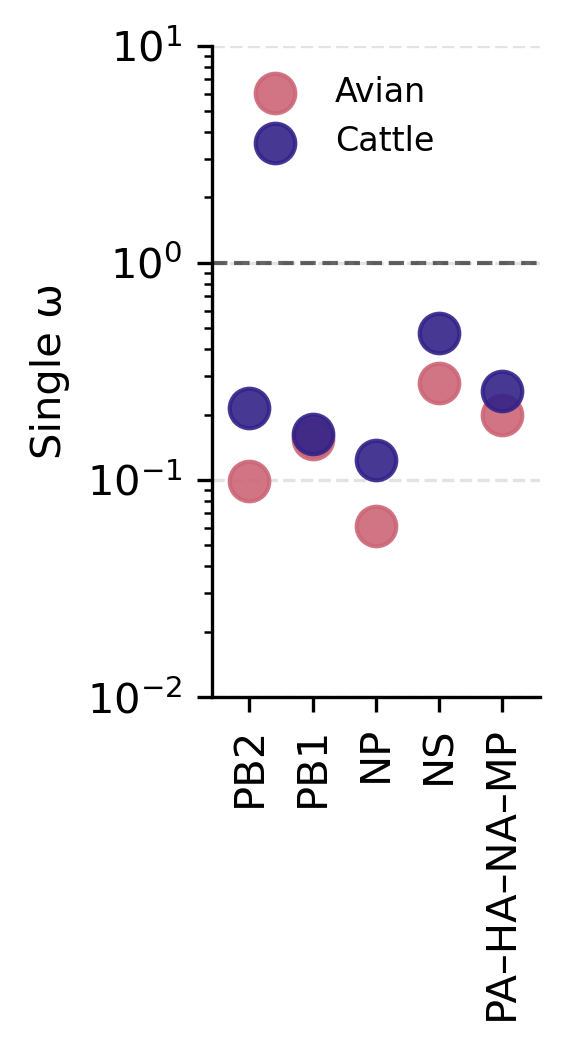

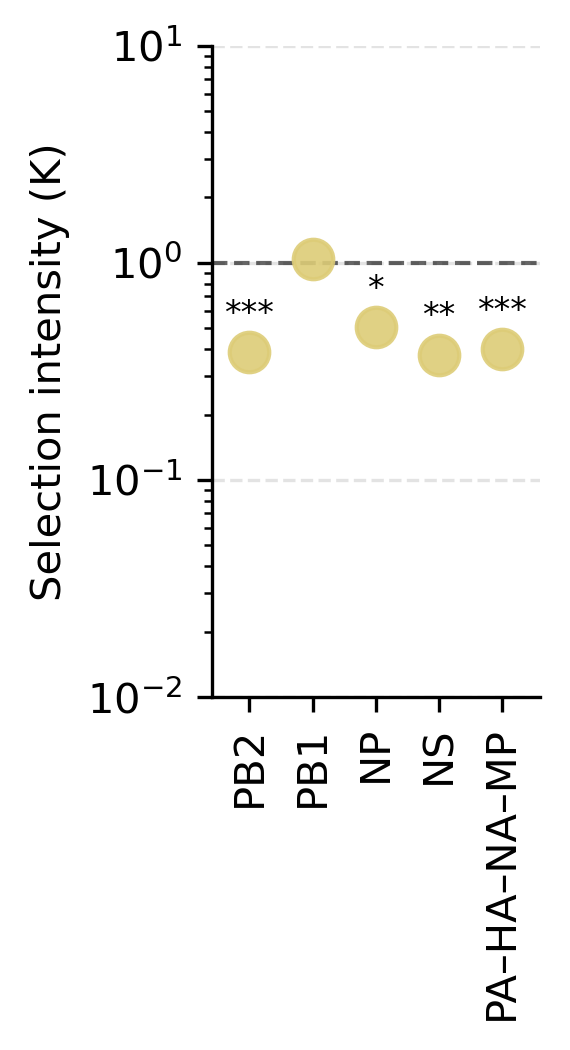

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# segments in the order you want to plot
segments_plot = ['PB2', 'PB1', 'NP', 'NS', 'PA_HA_NA_MP']
pretty_labels = {
    'PB2': 'PB2',
    'PB1': 'PB1',
    'NP': 'NP',
    'NS': 'NS',
    'PA_HA_NA_MP': 'PA–HA–NA–MP'
}

def pick_best_model(seg_results):
    """
    seg_results: hyphy_results[seg], e.g. {'2rateSyn': {...}, '3rateSyn': {...}}
    Returns the key ('2rateSyn' or '3rateSyn') with the highest Log Likelihood
    under the RELAX alternative fit.
    """
    def logL(model_key):
        return seg_results[model_key]["parameters"]["Log Likelihood"]
    return max(seg_results.keys(), key=logL)


def get_single_omegas(omega_dict):
    """
    omega_dict is hyphy_results[seg][model]['omega'], i.e. the
    'Rate Distributions' from:
      "MG94xREV with separate rates for branch sets" -> "Rate Distributions"

    Example structure:
    {
      'non-synonymous/synonymous rate ratio for *Reference*': [[0.2796, 1]],
      'non-synonymous/synonymous rate ratio for *Test*': [[0.4730, 1]],
      'non-synonymous/synonymous rate ratio for *Unclassified*': [[23.95, 1]]
    }

    Returns (omega_ref, omega_test).
    """
    ref_key = [k for k in omega_dict.keys() if "Reference" in k][0]
    test_key = [k for k in omega_dict.keys() if "Test" in k][0]

    omega_ref = omega_dict[ref_key][0][0]
    omega_test = omega_dict[test_key][0][0]
    return omega_ref, omega_test

omega_ref_list = []
omega_test_list = []
K_list = []
p_list = []

for seg in segments_plot:
    seg_results = hyphy_results[seg]
    best_model_key = pick_best_model(seg_results)

    params = seg_results[best_model_key]["parameters"]      # RELAX alternative
    tests  = seg_results[best_model_key]["test results"]    # RELAX test results
    omega_dict = seg_results[best_model_key]["omega"]       # MG94xREV single ω

    # single ω from MG94xREV with separate rates
    omega_ref, omega_test = get_single_omegas(omega_dict)

    # RELAX K and p-value
    K = tests["relaxation or intensification parameter"]
    p = tests["p-value"]

    omega_ref_list.append(omega_ref)
    omega_test_list.append(omega_test)
    K_list.append(K)
    p_list.append(p)

segments_labels = [pretty_labels[s] for s in segments_plot]
x = np.arange(len(segments_plot))

omega_ref = np.array(omega_ref_list)
omega_test = np.array(omega_test_list)
K_vals = np.array(K_list)
p_vals = np.array(p_list)

grey = "#4a4a4a"
red = "#c23b22"

# ---------- Figure 1: Single ω ----------
fig1, ax1 = plt.subplots(figsize=(2, 3.6), dpi=300)

ax1.scatter(x, omega_ref, s=90, marker='o', alpha=0.9,
            color=color_avian, label="Avian", zorder=2)
ax1.scatter(x, omega_test, s=90, marker='o', alpha=0.9,
            color=color_cattle, label="Cattle", zorder=3)
ax1.axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)

ax1.set_yscale("log")
ax1.set_ylim(0.01, 10)

ax1.set_xticks(x)
ax1.set_xticklabels(segments_labels, rotation=90)
ax1.set_xlim(-0.6, len(segments_plot) - 0.4)
ax1.set_ylabel("Single ω", fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.legend(frameon=False, fontsize=8, loc="upper left")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

fig1.tight_layout()
# fig1.savefig("relax_multi_single_omega_colored.pdf", bbox_inches="tight")

# ---------- Figure 2: Selection intensity (K) ----------
fig2, ax2 = plt.subplots(figsize=(2, 3.6), dpi=300)

ax2.scatter(x, K_vals, s=90, marker='o', alpha=0.9, color=cset[2], zorder=3)
ax2.axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
ax2.set_yscale("log")
ax2.set_ylim(0.01, 10)
ax2.set_xticks(x)
ax2.set_xticklabels(segments_labels, rotation=90)
ax2.set_xlim(-0.6, len(segments_plot) - 0.4)
ax2.set_ylabel("Selection intensity (K)", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

for xi, Ki, pi in zip(x, K_vals, p_vals):
    s = stars(pi)
    if s:
        ax2.text(xi, Ki * 1.25, s, ha="center", va="bottom", fontsize=8)

fig2.tight_layout()
# fig2.savefig("relax_multi_K_colored.pdf", bbox_inches="tight")
# plt.show()


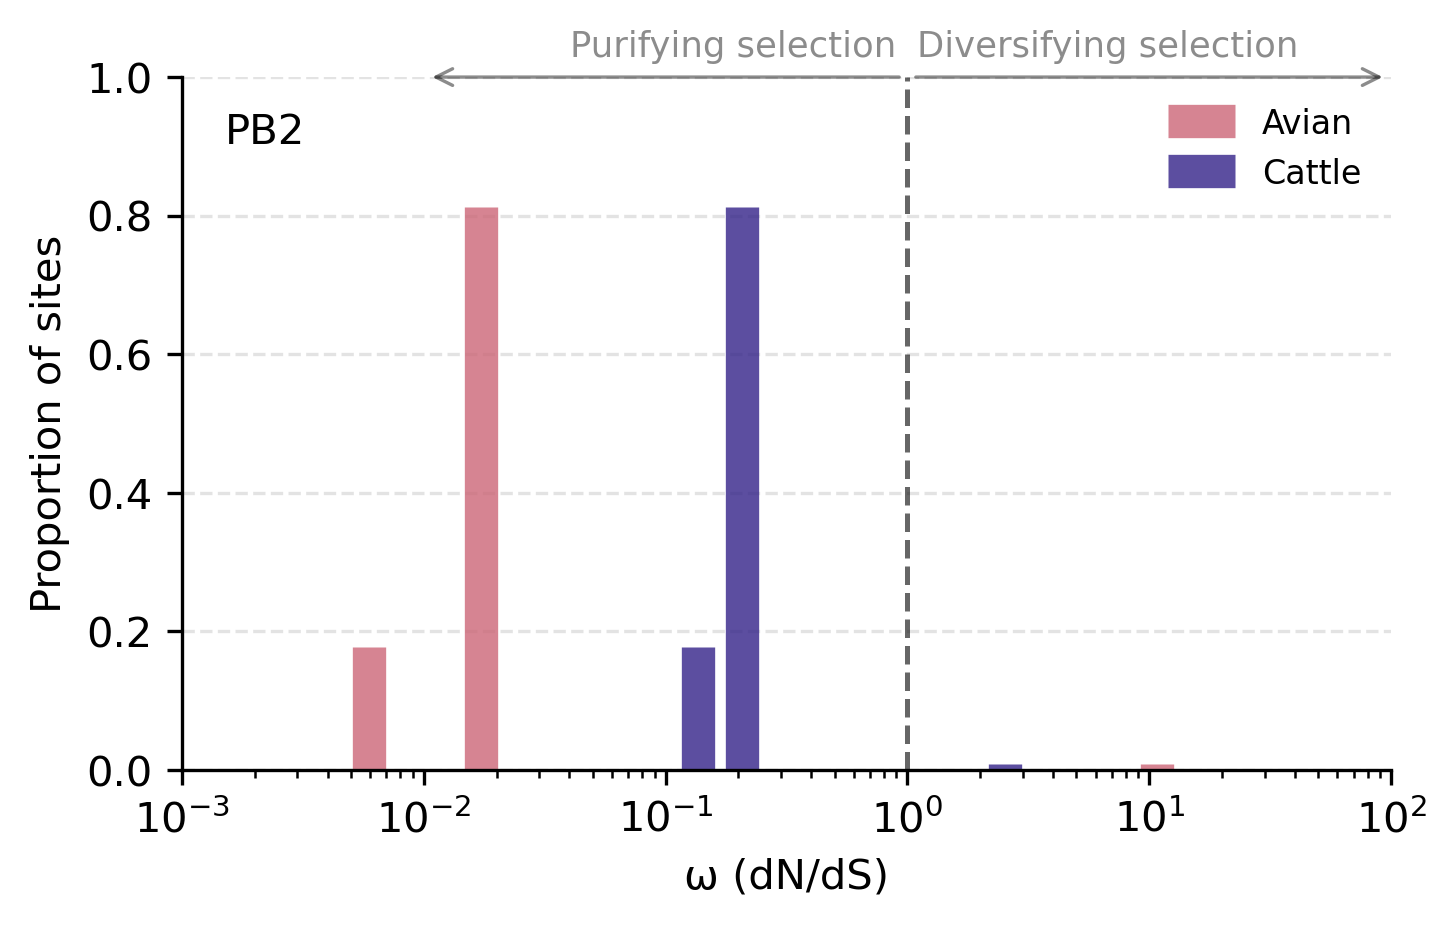

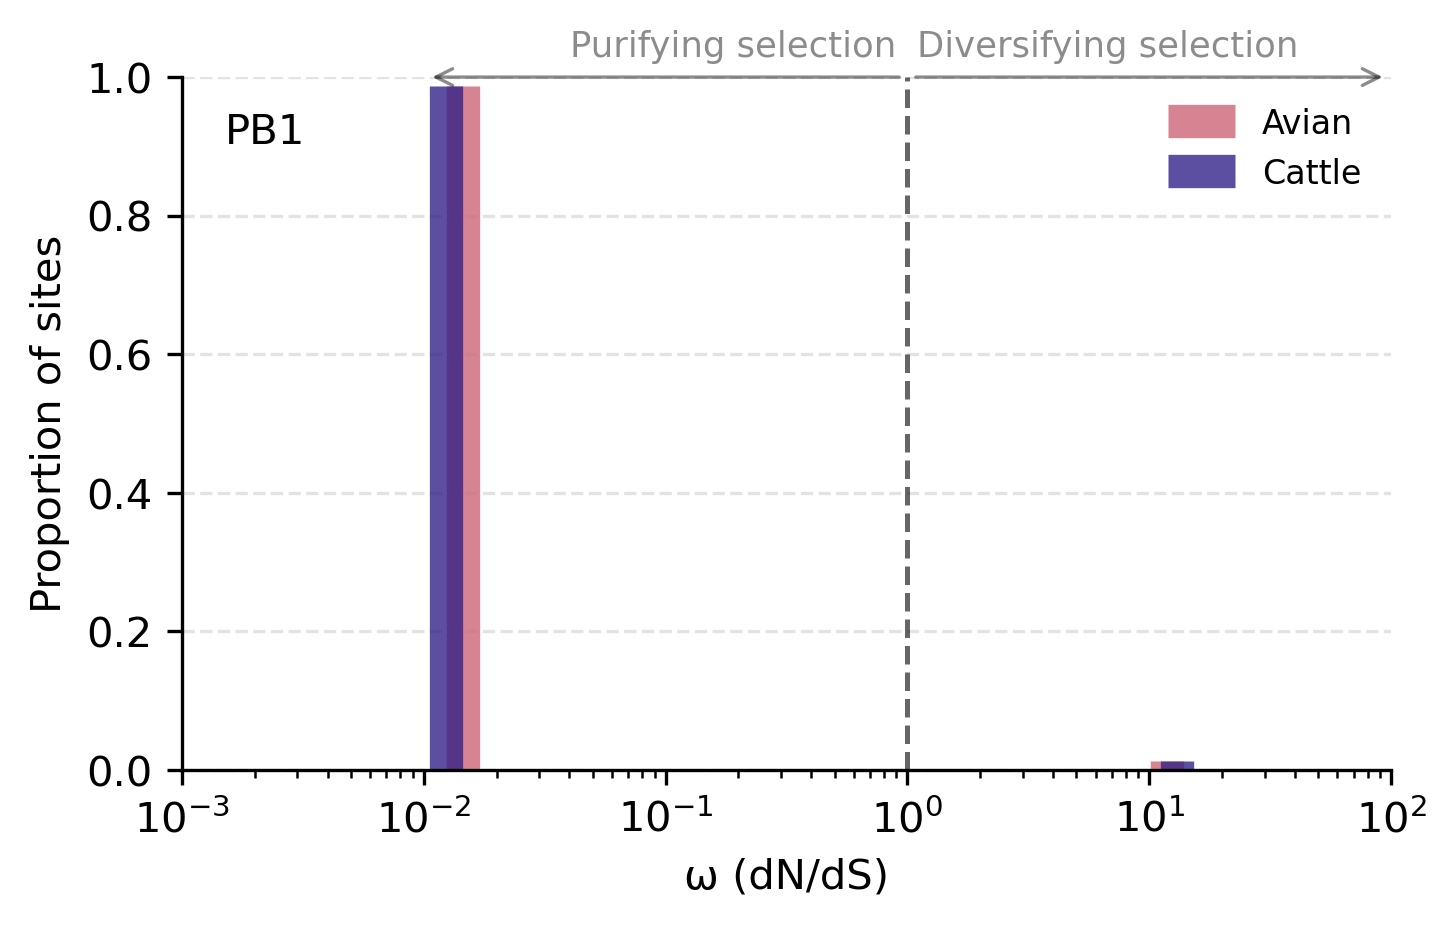

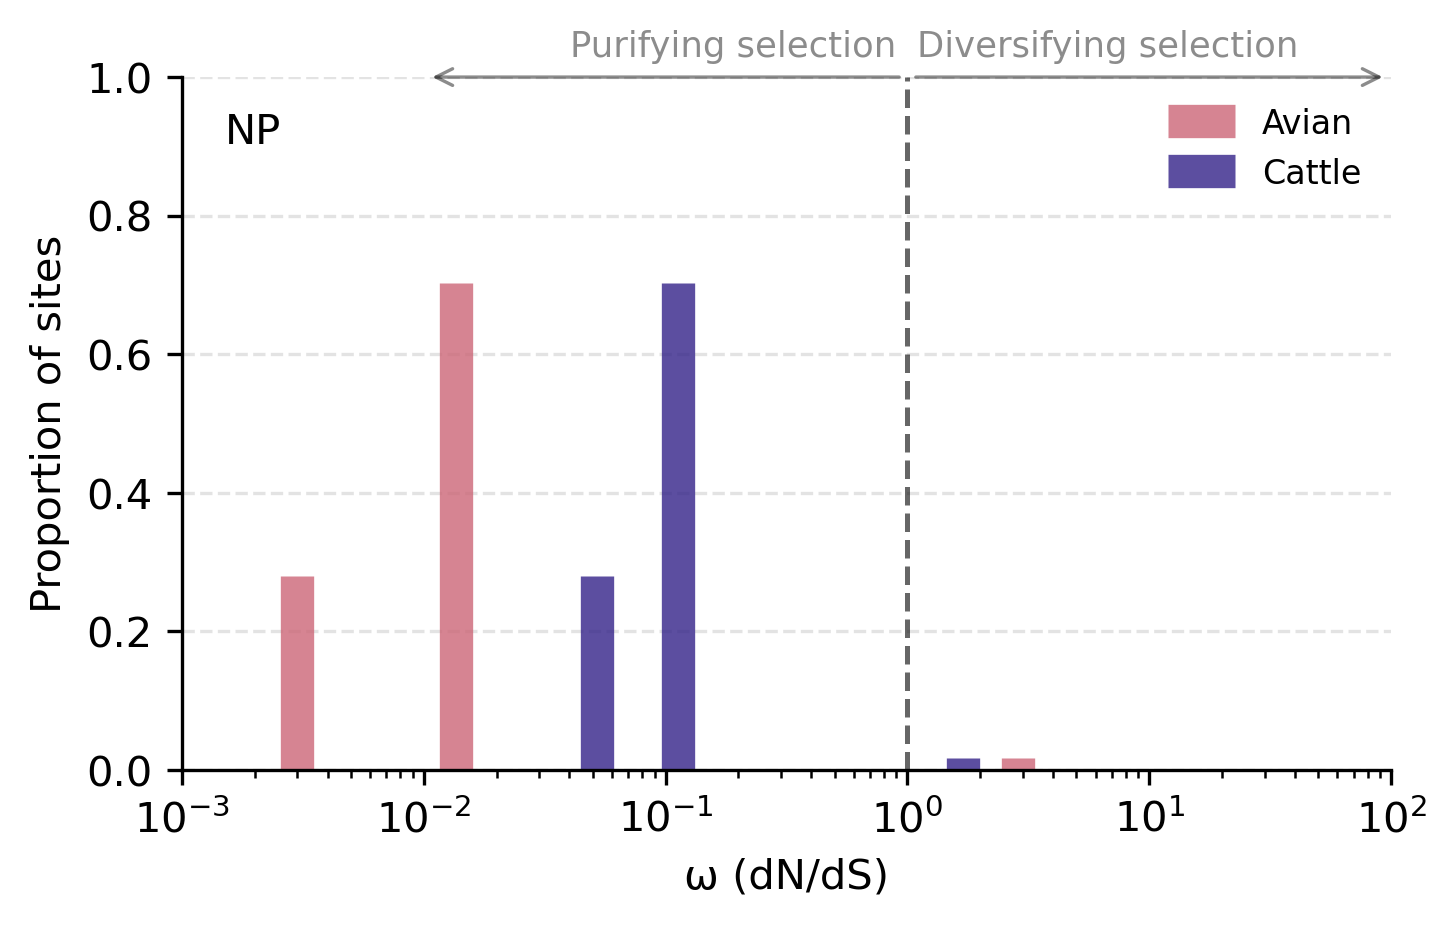

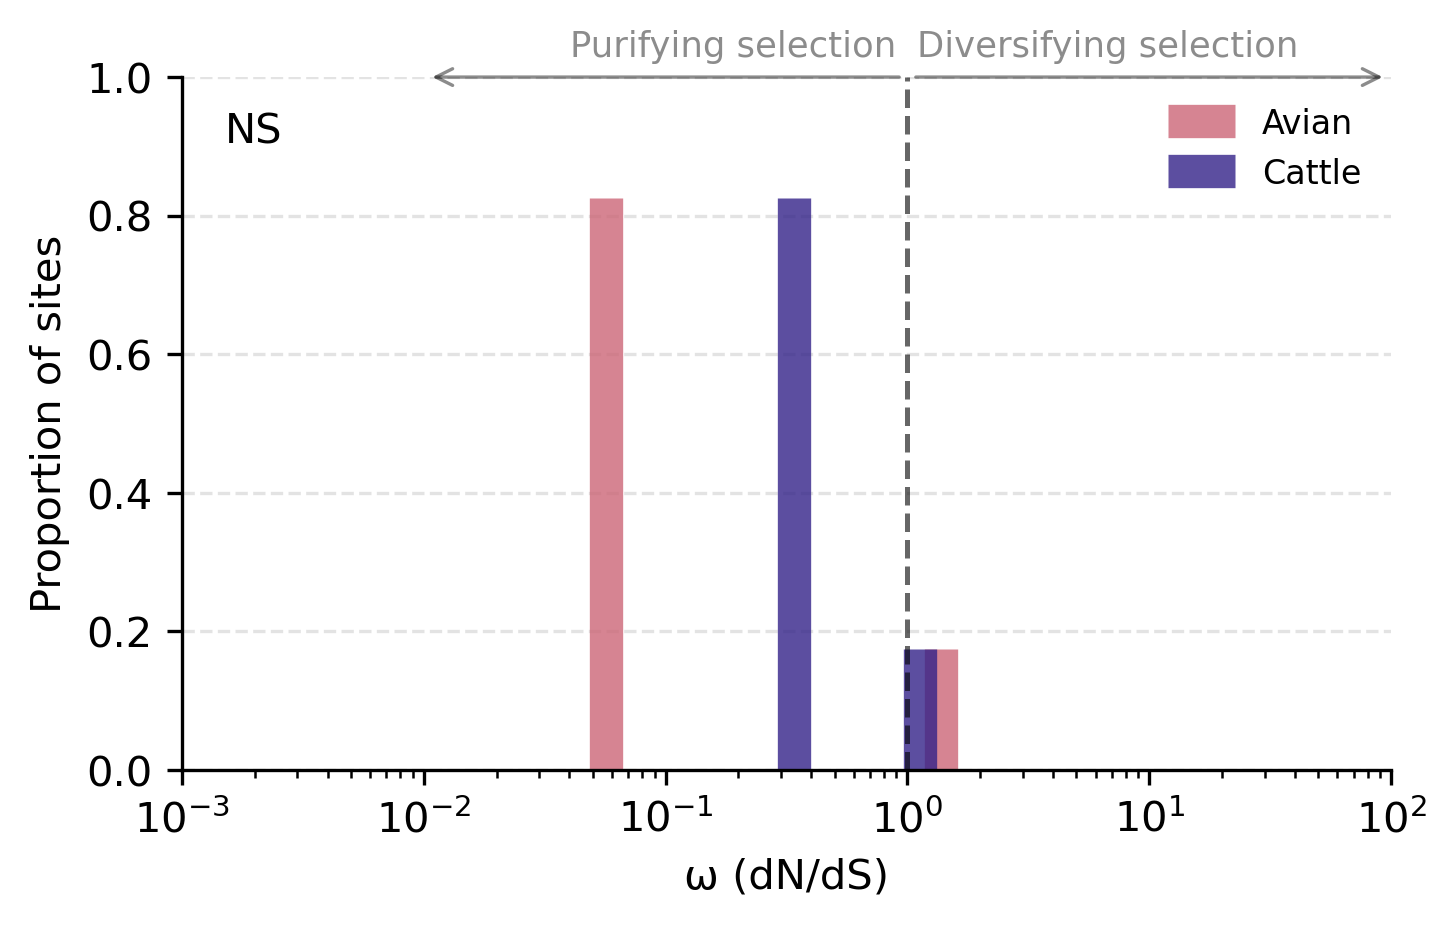

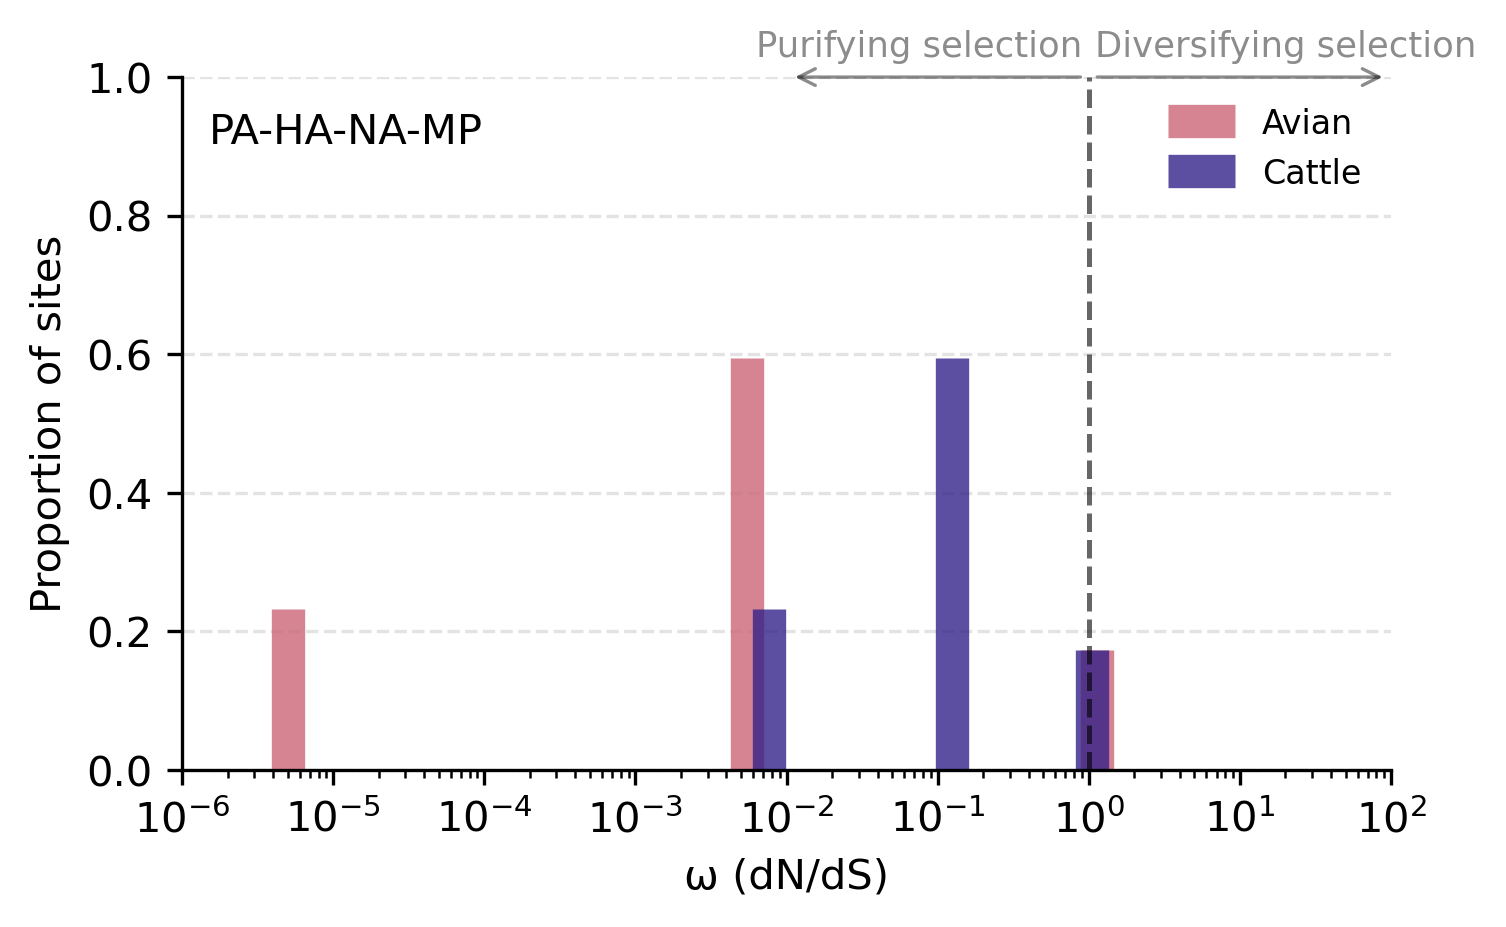

In [8]:
def plot_alternative_models(hyphy_results, segment=None, legend=True, figsize=(5.2, 3), ax=None):
    alt = hyphy_results['parameters']
    ref_dist = alt["Rate Distributions"]["Reference"]
    test_dist = alt["Rate Distributions"]["Test"]

    keys = sorted(ref_dist.keys(), key=lambda x: int(x))
    omega_ref = np.array([float(ref_dist[k]["omega"]) for k in keys])
    omega_test = np.array([float(test_dist[k]["omega"]) for k in keys])
    prop_ref = np.array([float(ref_dist[k]["proportion"]) for k in keys], dtype=float)
    prop_test = np.array([float(test_dist[k]["proportion"]) for k in keys], dtype=float)

    # Normalize proportions just in case
    prop_ref = prop_ref / prop_ref.sum()
    prop_test = prop_test / prop_test.sum()

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=300)

    ax.vlines(omega_ref, 0, prop_ref, colors=color_avian, linewidth=8,
              label="Avian", alpha=0.8)
    ax.vlines(omega_test, 0, prop_test, colors=color_cattle, linewidth=8,
              label="Cattle", alpha=0.8)
    ax.axvline(1.0, linestyle="--", linewidth=1.2, color="black", alpha=0.6)

    ax.set_xlabel("ω (dN/dS)", fontsize=10)
    ax.set_ylabel("Proportion of sites", fontsize=10)
    if legend:
        ax.legend(frameon=False, fontsize=8, loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    # --- log-scale x-limits based on data ---
    all_omegas = np.concatenate([omega_ref, omega_test])

    log_min = np.floor(np.log10(all_omegas.min()))
    log_max = np.ceil(np.log10(all_omegas.max()))

    xmin = min(0.001, 10 ** log_min)
    xmax = max(100, 10 ** log_max)

    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # --- Add faint region labels ---
    ax.text(0.9, 1.02, "Purifying selection", ha="right", va="bottom",
            fontsize=8.5, color="black", alpha=0.45, transform=ax.transData)
    ax.text(1.1, 1.02, "Diversifying selection", ha="left", va="bottom",
            fontsize=8.5, color="black", alpha=0.45, transform=ax.transData)

    # --- Add small directional arrows under labels ---
    # Left arrow (← under "Purifying selection")
    ax.annotate(
        "", xy=(1, 1), xytext=(0.01, 1),
        arrowprops=dict(arrowstyle="<-", color="black", lw=0.8, alpha=0.45)
    )

    # Right arrow (→ under "Diversifying selection")
    ax.annotate(
        "", xy=(100, 1), xytext=(1, 1),
        arrowprops=dict(arrowstyle="->", color="black", lw=0.8, alpha=0.45)
    )
    
    # --- Add text indicating segment name ---
    if segment:
        ax.text(xmin*1.5, 0.95, segment.replace('_','-'), ha="left", va="top",
                fontsize=10, color="black",
                transform=ax.transData)

    if ax is None:
        fig.tight_layout()


segments_plot = ['PB2', 'PB1', 'NP', 'NS', 'PA_HA_NA_MP']
for seg in segments_plot:
    seg_results = hyphy_results[seg]
    best_model_key = pick_best_model(seg_results)
    plot_alternative_models(seg_results[best_model_key], segment=seg)

# all in 1 figure

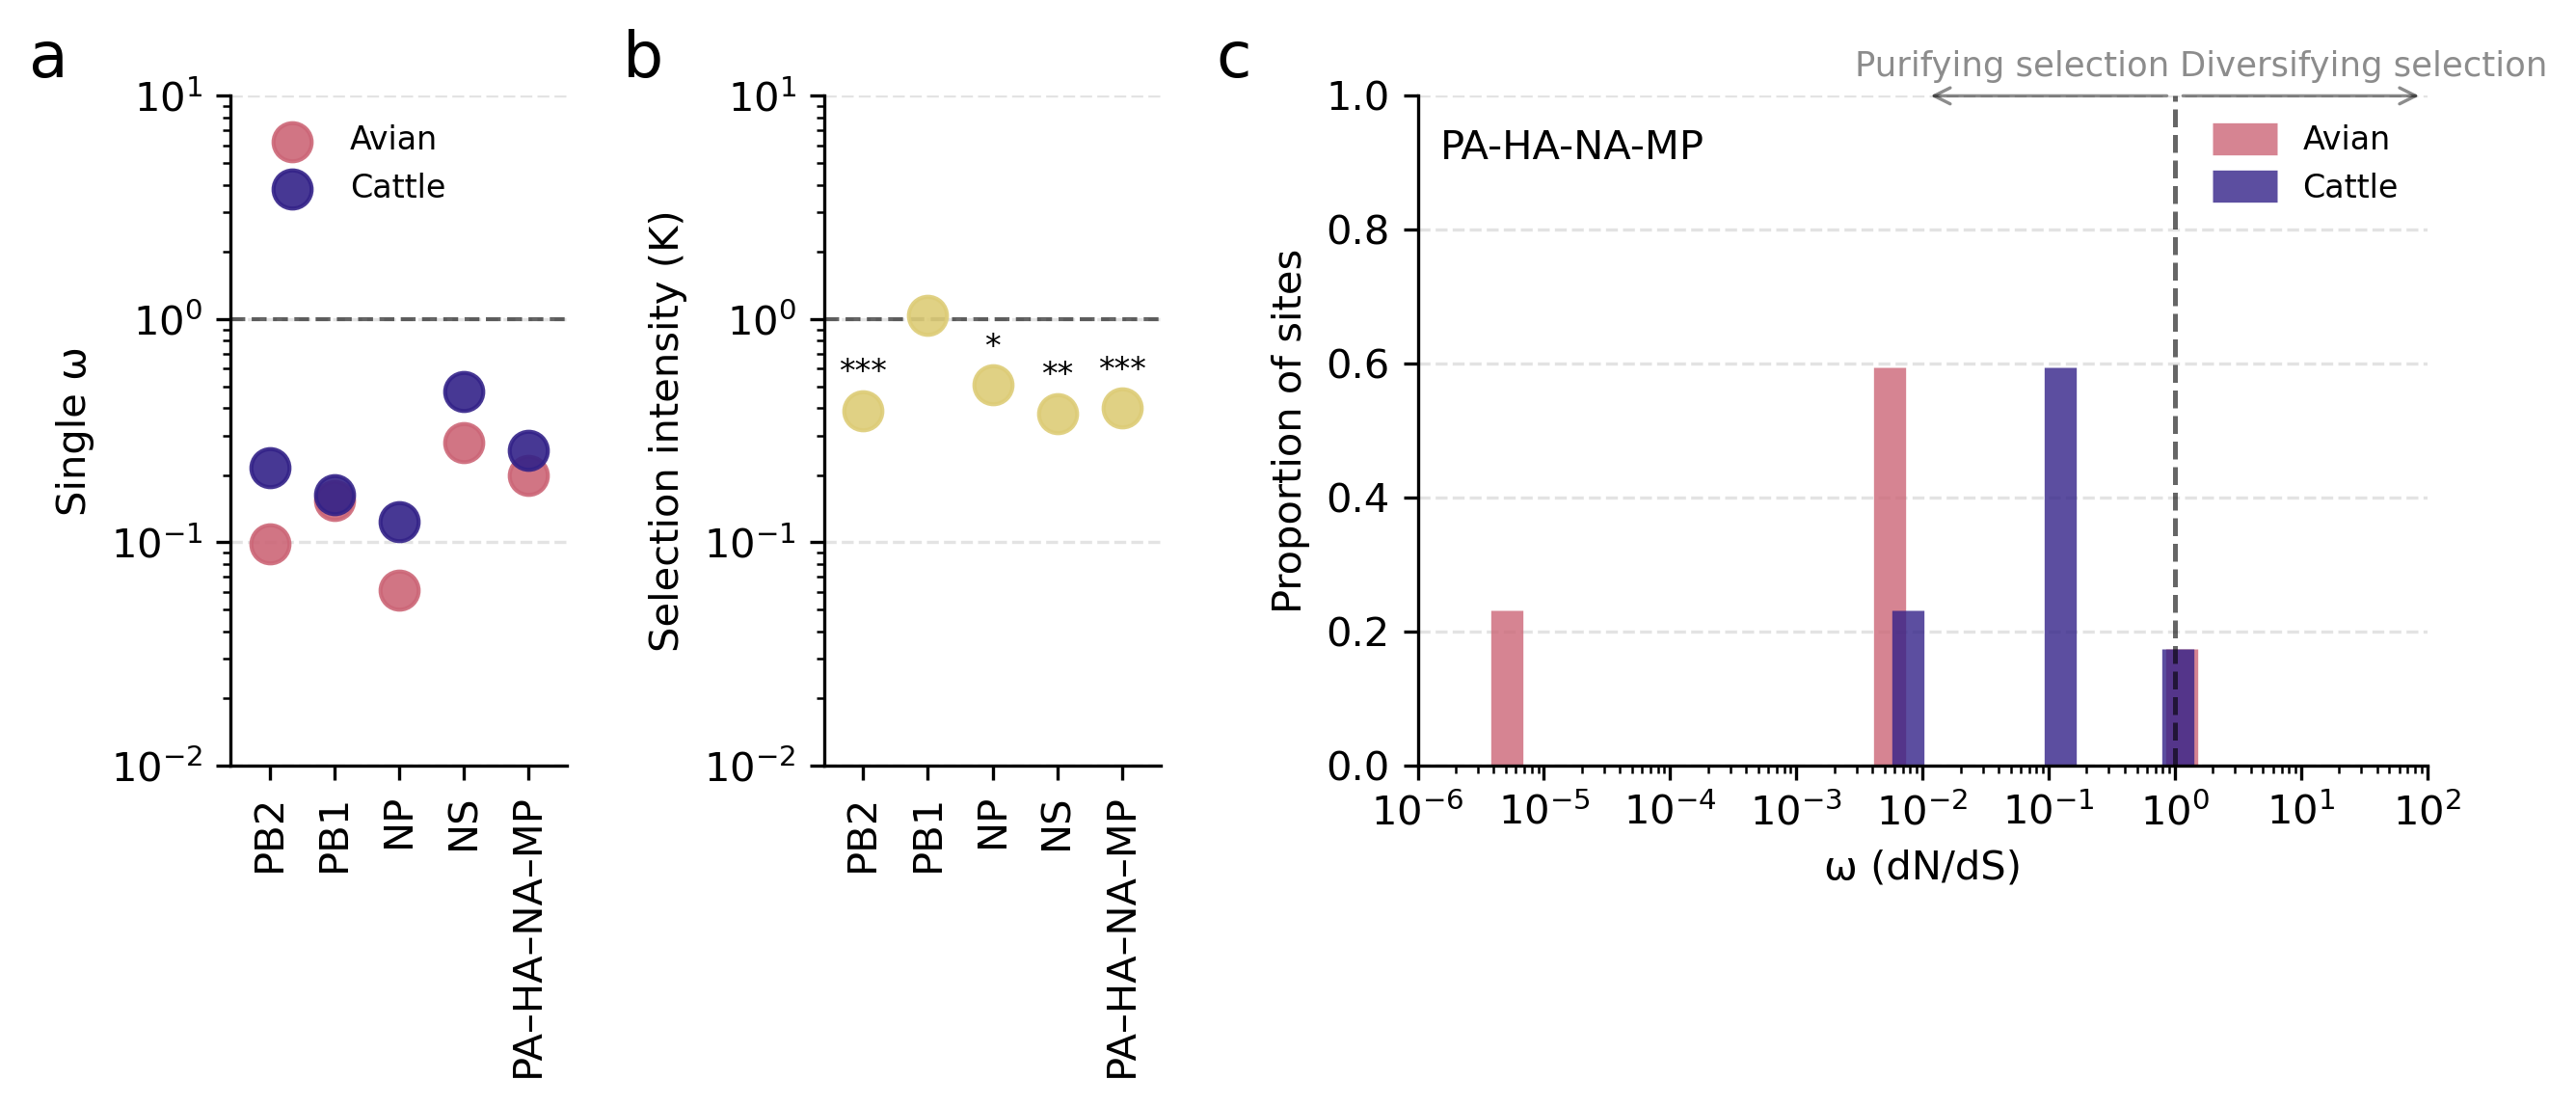

In [9]:
# ---------- Figure 1: Single ω ----------
# subplots, different sizes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 4), dpi=300,
                         gridspec_kw={'width_ratios': [1, 1, 3]})

axes[0].scatter(x, omega_ref, s=90, marker='o', alpha=0.9,
            color=color_avian, label="Avian", zorder=2)
axes[0].scatter(x, omega_test, s=90, marker='o', alpha=0.9,
            color=color_cattle, label="Cattle", zorder=3)
axes[0].axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)

axes[0].set_yscale("log")
axes[0].set_ylim(0.01, 10)

axes[0].set_xticks(x)
axes[0].set_xticklabels(segments_labels, rotation=90)
axes[0].set_xlim(-0.6, len(segments_plot) - 0.4)
axes[0].set_ylabel("Single ω", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ---------- Figure 2: Selection intensity (K) ----------
axes[1].scatter(x, K_vals, s=90, marker='o', alpha=0.9, color=cset[2], zorder=3)
axes[1].axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[1].set_yscale("log")
axes[1].set_ylim(0.01, 10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(segments_labels, rotation=90)
axes[1].set_xlim(-0.6, len(segments_plot) - 0.4)
axes[1].set_ylabel("Selection intensity (K)", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

for xi, Ki, pi in zip(x, K_vals, p_vals):
    s = stars(pi)
    if s:
        axes[1].text(xi, Ki * 1.25, s, ha="center", va="bottom", fontsize=8)


# ---------- Figure 3: RELAX alternative models ----------
seg = 'PA_HA_NA_MP'
seg_results = hyphy_results[seg]
best_model_key = pick_best_model(seg_results)
plt.sca(axes[2])
plot_alternative_models(
    seg_results[best_model_key],
    segment=seg,
    legend=True,
    ax=axes[2],
)

axes[0].text(-.6, 1.1, 'a', transform=axes[0].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
axes[1].text(-.6, 1.1, 'b', transform=axes[1].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
axes[2].text(-.2, 1.1, 'c', transform=axes[2].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
fig.tight_layout()


# D1.1

In [10]:
import json
import os

d11_hyphy_dir = '../analysis/d11/hyphy/D11_RELAX_FUBAR/'
d11_hyphy_results = {seg: {} for seg in ['Coding regions']}
seg = 'Coding regions'

# save RELAX alternative model data for all segments
for f in os.listdir(d11_hyphy_dir):
    if f.endswith('rateSyn.json'):
        with open(os.path.join(d11_hyphy_dir, f)) as jf:
            data = json.load(jf)
        d11_hyphy_results[seg][f.split('.')[-2]] = {}
        d11_hyphy_results[seg][f.split('.')[-2]]['parameters'] = data['fits']['RELAX alternative']
        d11_hyphy_results[seg][f.split('.')[-2]]['test results'] = data['test results']
        d11_hyphy_results[seg][f.split('.')[-2]]['omega'] = data['fits']["MG94xREV with separate rates for branch sets"]["Rate Distributions"]
        


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_41954/1854740133.py:88: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig1.tight_layout()
/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_41954/1854740133.py:110: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig2.tight_layout()


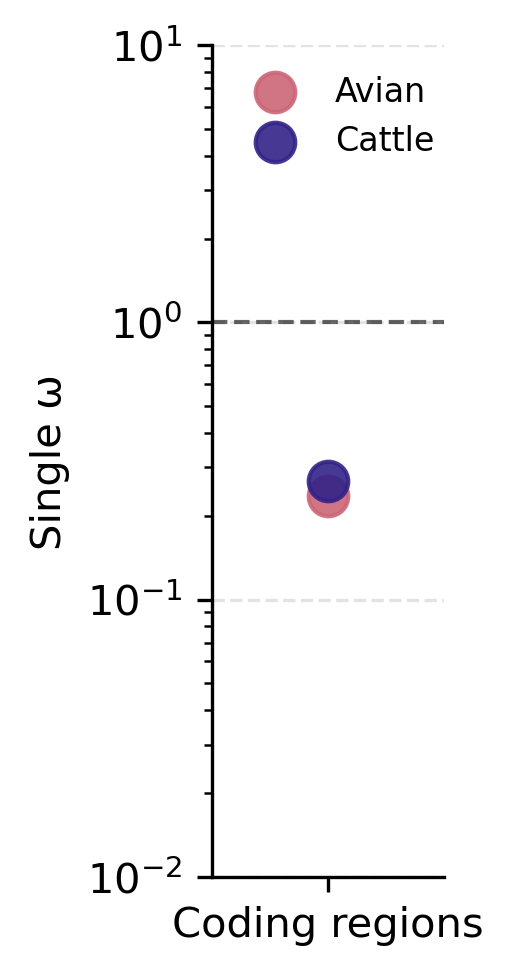

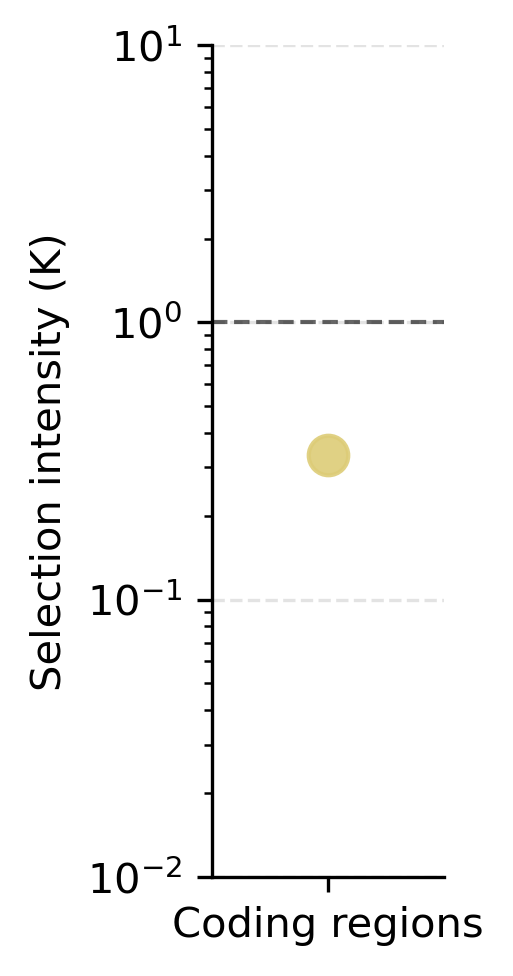

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ------- helpers (same as before) -------

def pick_best_model(seg_results):
    """
    seg_results: d11_hyphy_results[seg], e.g. {'2rateSyn': {...}, '3rateSyn': {...}}
    Returns the key ('2rateSyn' or '3rateSyn') with the highest Log Likelihood
    under the RELAX alternative fit.
    """
    def logL(model_key):
        return seg_results[model_key]["parameters"]["Log Likelihood"]
    return max(seg_results.keys(), key=logL)


def get_single_omegas(omega_dict):
    """
    omega_dict is d11_hyphy_results[seg][model]['omega'], i.e. the
    'Rate Distributions' from:
      "MG94xREV with separate rates for branch sets" -> "Rate Distributions"

    Example structure:
    {
      'non-synonymous/synonymous rate ratio for *Reference*': [[0.2796, 1]],
      'non-synonymous/synonymous rate ratio for *Test*': [[0.4730, 1]],
      'non-synonymous/synonymous rate ratio for *Unclassified*': [[23.95, 1]]
    }

    Returns (omega_ref, omega_test).
    """
    ref_key = [k for k in omega_dict.keys() if "Reference" in k][0]
    test_key = [k for k in omega_dict.keys() if "Test" in k][0]

    omega_ref = omega_dict[ref_key][0][0]
    omega_test = omega_dict[test_key][0][0]
    return omega_ref, omega_test


# ------- extract from d11_hyphy_results -------

seg = "Coding regions"
seg_results = d11_hyphy_results[seg]

best_model_key = pick_best_model(seg_results)

params     = seg_results[best_model_key]["parameters"]      # RELAX alternative
tests      = seg_results[best_model_key]["test results"]    # RELAX test results
omega_dict = seg_results[best_model_key]["omega"]           # MG94xREV single ω

omega_ref, omega_test = get_single_omegas(omega_dict)
K = tests["relaxation or intensification parameter"]
p = tests["p-value"]

segments_plot   = [seg]              # just one segment
segments_labels = ["Coding regions"] # pretty label
x = np.arange(len(segments_plot))    # will be array([0])

omega_ref_arr = np.array([omega_ref])
omega_test_arr = np.array([omega_test])
K_vals = np.array([K])
p_vals = np.array([p])

grey = "#4a4a4a"
red = "#c23b22"

# ---------- Figure 1: Single ω ----------
fig1, ax1 = plt.subplots(figsize=(1, 3.6), dpi=300)

ax1.scatter(x, omega_ref_arr, s=90, marker='o', alpha=0.9,
            color=color_avian, label="Avian", zorder=2)
ax1.scatter(x, omega_test_arr, s=90, marker='o', alpha=0.9,
            color=color_cattle, label="Cattle", zorder=3)
ax1.axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)

ax1.set_yscale("log")
ax1.set_ylim(0.01, 10)

ax1.set_xticks(x)
ax1.set_xticklabels(segments_labels)
ax1.set_xlim(-0.6, 0.6)
ax1.set_ylabel("Single ω", fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.legend(frameon=False, fontsize=8, loc="upper left")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

fig1.tight_layout()
# fig1.savefig("d11_relax_single_omega.pdf", bbox_inches="tight")

# ---------- Figure 2: Selection intensity (K) ----------
fig2, ax2 = plt.subplots(figsize=(1, 3.6), dpi=300)

ax2.scatter(x, K_vals, s=90, marker='o', alpha=0.9, color=cset[2], zorder=3)
ax2.axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
ax2.set_yscale("log")
ax2.set_ylim(0.01, 10)
ax2.set_xticks(x)
ax2.set_xticklabels(segments_labels)
ax2.set_xlim(-0.6, 0.6)
ax2.set_ylabel("Selection intensity (K)", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

s = stars(p_vals[0])
if s:
    ax2.text(x[0], K_vals[0] * 1.25, s, ha="center", va="bottom", fontsize=11)

fig2.tight_layout()
# fig2.savefig("d11_relax_K.pdf", bbox_inches="tight")
# plt.show()


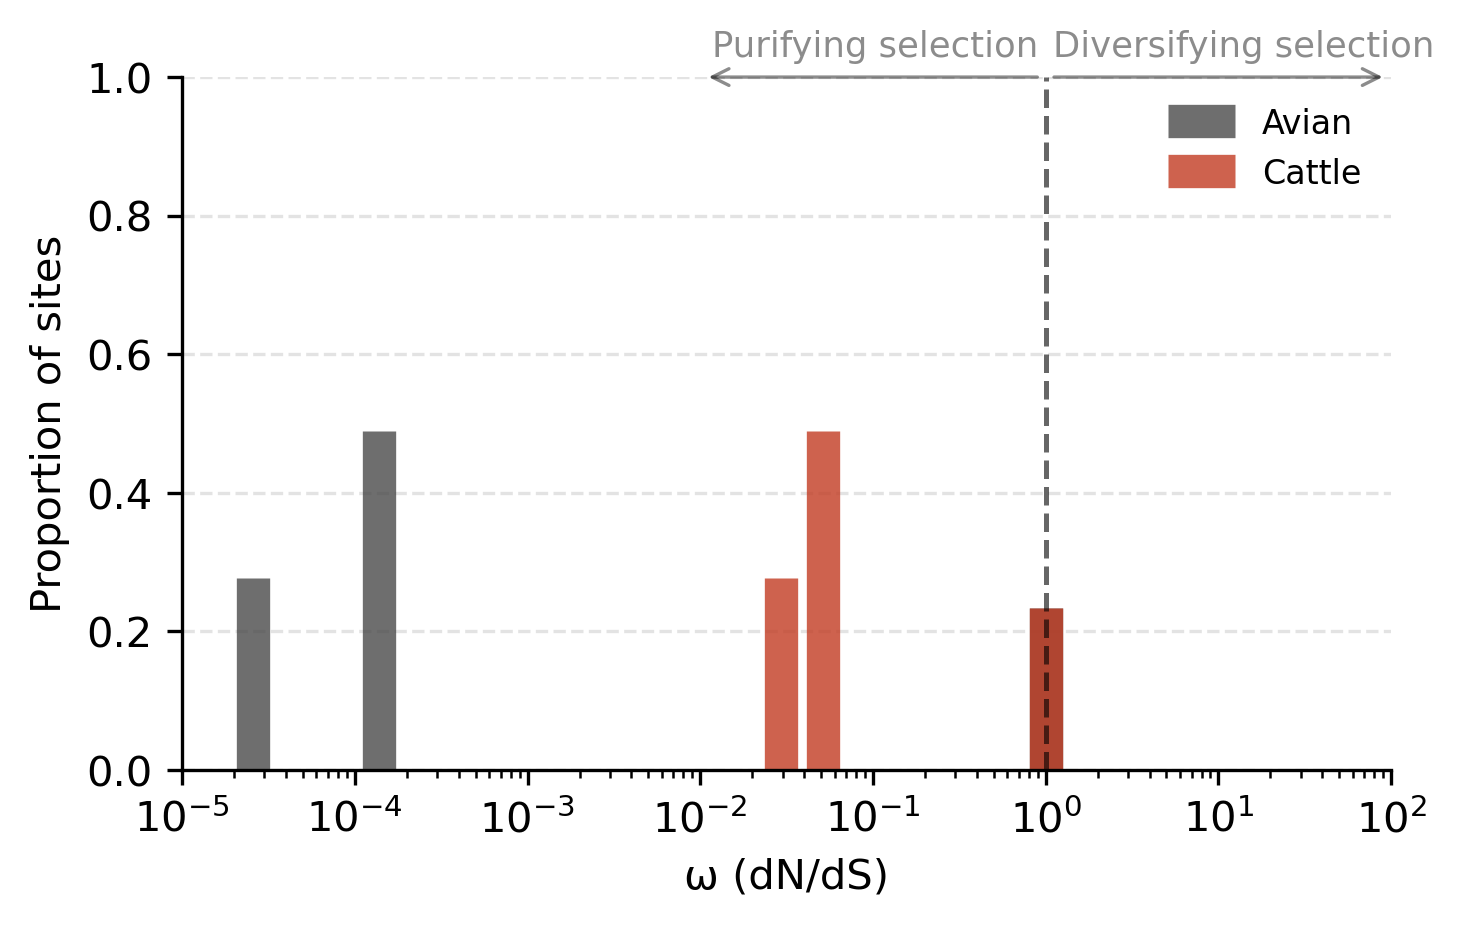

In [7]:
segments_plot = ['Coding regions']
for seg in segments_plot:
    seg_results = d11_hyphy_results[seg]
    best_model_key = pick_best_model(seg_results)
    plot_alternative_models(seg_results[best_model_key])

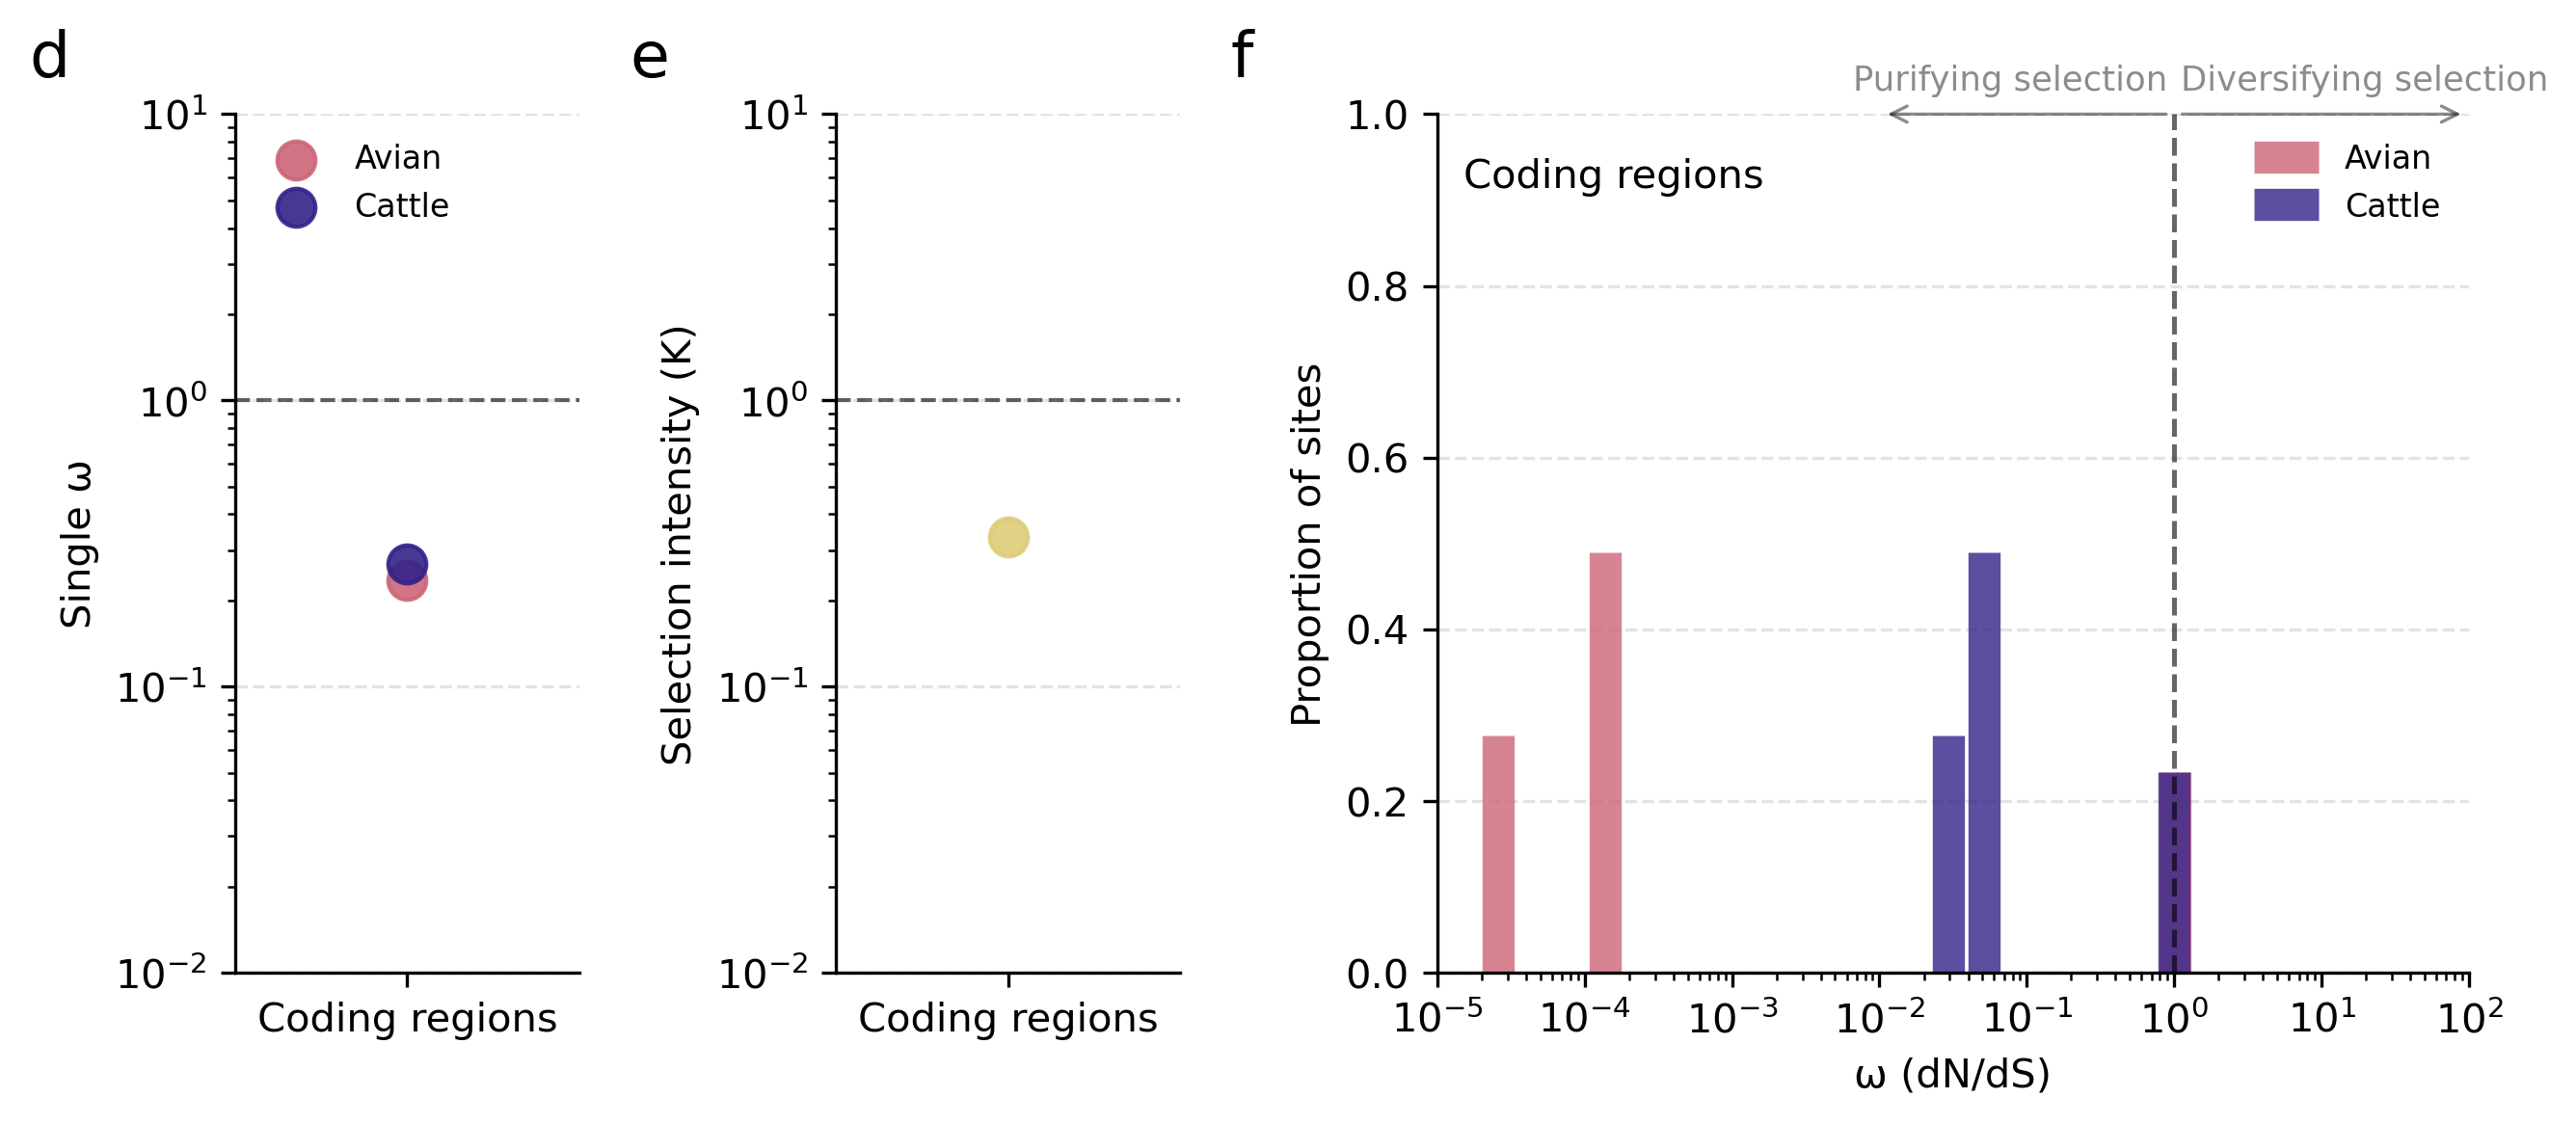

In [12]:
# ---------- Figure 1: Single ω ----------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 4), dpi=300,
                         gridspec_kw={'width_ratios': [1, 1, 3]})

axes[0].scatter(x, omega_ref_arr, s=90, marker='o', alpha=0.9,
            color=color_avian, label="Avian", zorder=2)
axes[0].scatter(x, omega_test_arr, s=90, marker='o', alpha=0.9,
            color=color_cattle, label="Cattle", zorder=3)
axes[0].axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[0].set_yscale("log")
axes[0].set_ylim(0.01, 10)

axes[0].set_xticks(x)
axes[0].set_xticklabels(segments_labels)
axes[0].set_xlim(-0.6, 0.6)
axes[0].set_ylabel("Single ω", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ---------- Figure 2: Selection intensity (K) ----------
axes[1].scatter(x, K_vals, s=90, marker='o', alpha=0.9, color=cset[2], zorder=3)
axes[1].axhline(1.0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[1].set_yscale("log")
axes[1].set_ylim(0.01, 10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(segments_labels)
axes[1].set_xlim(-0.6, 0.6)
axes[1].set_ylabel("Selection intensity (K)", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

s = stars(p_vals[0])
if s:
    axes[1].text(x[0], K_vals[0] * 1.25, s, ha="center", va="bottom", fontsize=11)
    
    
# ---------- Figure 3: RELAX alternative models ----------
seg = 'Coding regions'
seg_results = d11_hyphy_results[seg]
best_model_key = pick_best_model(seg_results)
plt.sca(axes[2])
plot_alternative_models(
    seg_results[best_model_key],
    segment=seg,
    legend=True,
    ax=axes[2],
)

axes[0].text(-.6, 1.1, 'd', transform=axes[0].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
axes[1].text(-.6, 1.1, 'e', transform=axes[1].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
axes[2].text(-.2, 1.1, 'f', transform=axes[2].transAxes,
            fontsize=16, fontweight='normal', va='top', ha='left')
fig.tight_layout()

# Table

In [ ]:
import numpy as np
import pandas as pd


# ----------------------------
# Model selection (by logL)
# ----------------------------
def pick_best_model(seg_results, syns=("2rateSyn", "3rateSyn")):
    """
    seg_results: hyphy_results[seg], e.g. {'2rateSyn': {...}, '3rateSyn': {...}}
    Returns the key (e.g. '2rateSyn' or '3rateSyn') with the highest Log Likelihood
    under the RELAX alternative fit.
    """
    def logL(model_key):
        return seg_results[model_key]["parameters"]["Log Likelihood"]
    return max(syns, key=logL)


# ----------------------------
# Extract RELAX alternative buckets (ω + proportion per host)
# ----------------------------
def extract_rate_distributions(model_block):
    """
    model_block: seg_results[syn] for a given segment and syn category.

    Returns a DataFrame with one row per rate bucket:
      bucket, omega_ref, prop_ref, omega_test, prop_test
    """
    alt = model_block["parameters"]
    ref_dist = alt["Rate Distributions"]["Reference"]
    test_dist = alt["Rate Distributions"]["Test"]

    # keys are typically strings like "0","1","2" — sort numerically
    keys = sorted(ref_dist.keys(), key=lambda x: int(x))

    omega_ref  = np.array([float(ref_dist[k]["omega"]) for k in keys], dtype=float)
    omega_test = np.array([float(test_dist[k]["omega"]) for k in keys], dtype=float)
    prop_ref   = np.array([float(ref_dist[k]["proportion"]) for k in keys], dtype=float)
    prop_test  = np.array([float(test_dist[k]["proportion"]) for k in keys], dtype=float)

    # Normalize proportions defensively
    if np.isfinite(prop_ref).all() and prop_ref.sum() > 0:
        prop_ref = prop_ref / prop_ref.sum()
    if np.isfinite(prop_test).all() and prop_test.sum() > 0:
        prop_test = prop_test / prop_test.sum()

    return pd.DataFrame({
        "bucket": [int(k) for k in keys],
        "omega_ref": omega_ref,
        "prop_ref": prop_ref,
        "omega_test": omega_test,
        "prop_test": prop_test,
    })


# ----------------------------
# Build tables: summary + bucket-level
# ----------------------------
def build_relax_tables(hyphy_results, segments_plot, syns=("2rateSyn", "3rateSyn")):
    """
    Returns:
      df_summary: one row per (segment, syn_category)
      df_buckets: one row per (segment, syn_category, bucket)

    Requirements:
      - hyphy_results[seg][syn]["parameters"]["Log Likelihood"]
      - hyphy_results[seg][syn]["test results"]["relaxation or intensification parameter"]
      - hyphy_results[seg][syn]["test results"]["p-value"]
      - hyphy_results[seg][syn]["omega"] (for get_single_omegas)
      - hyphy_results[seg][syn]["parameters"]["Rate Distributions"]["Reference"/"Test"]
    """
    summary_rows = []
    bucket_rows = []

    for seg in segments_plot:
        seg_results = hyphy_results[seg]

        # per-segment logLs, to flag best syn model
        logLs = {syn: float(seg_results[syn]["parameters"]["Log Likelihood"]) for syn in syns}
        best_syn = max(logLs, key=logLs.get)

        for syn in syns:
            model = seg_results[syn]
            tests = model["test results"]
            omega_dict = model["omega"]

            # MG94xREV single ω (helper)
            omega_ref_single, omega_test_single = get_single_omegas(omega_dict)

            # number of buckets (2 for 2rateSyn, 3 for 3rateSyn, etc.)
            n_buckets = len(model["parameters"]["Rate Distributions"]["Reference"])

            # summary row
            summary_rows.append({
                "segment": seg,
                "syn_category": syn,
                "log_likelihood": logLs[syn],
                "is_best_syn": syn == best_syn,
                "omega_ref_single": omega_ref_single,
                "omega_test_single": omega_test_single,
                "K": tests["relaxation or intensification parameter"],
                "p_value": tests["p-value"],
                "n_buckets": n_buckets,
            })

            # bucket rows
            dist_df = extract_rate_distributions(model)
            dist_df.insert(0, "segment", seg)
            dist_df.insert(1, "syn_category", syn)
            bucket_rows.append(dist_df)

    df_summary = pd.DataFrame(summary_rows)
    df_buckets = pd.concat(bucket_rows, ignore_index=True) if bucket_rows else pd.DataFrame()

    return df_summary, df_buckets


# ----------------------------
# Make a single wide table per (segment, syn_category)
# ----------------------------
def make_wide_bucket_table(df_buckets):
    """
    Converts bucket-level long table into wide columns:
      omega_ref_b0, prop_ref_b0, omega_test_b0, prop_test_b0, ..., etc.
    """
    if df_buckets.empty:
        return df_buckets.copy()

    wide = df_buckets.pivot_table(
        index=["segment", "syn_category"],
        columns="bucket",
        values=["omega_ref", "prop_ref", "omega_test", "prop_test"],
        aggfunc="first",
    ).reset_index()

    wide.columns = [
        f"{a}_b{b}" if isinstance(b, (int, np.integer)) else a
        for (a, b) in wide.columns.to_flat_index()
    ]
    return wide


# ----------------------------
# Usage
# ----------------------------
segments_plot = ['PB2', 'PB1', 'NP', 'NS', 'PA_HA_NA_MP']
syns = ("2rateSyn", "3rateSyn")

df_summary, df_buckets = build_relax_tables(hyphy_results, segments_plot, syns=syns)

# If you want a single merged "paper table" (wide bucket columns):
df_buckets_wide = make_wide_bucket_table(df_buckets)
df_full = df_summary.merge(df_buckets_wide, on=["segment", "syn_category"], how="left")

# Pretty labels if desired:
df_full["segment"] = df_full["segment"].map(pretty_labels)

df_full

,segment,syn_category,log_likelihood,is_best_syn,omega_ref_single,omega_test_single,K,p_value,n_buckets,omega_ref_b0,...,omega_ref_b2,omega_test_b0,omega_test_b1,omega_test_b2,prop_ref_b0,prop_ref_b1,prop_ref_b2,prop_test_b0,prop_test_b1,prop_test_b2
0,PB2,2rateSyn,-23403.227641,False,0.098456,0.215075,1.663075,1.413285e-10,2,0.000000e+00,...,NaN,0.000000e+00,6.257077e+00,NaN,0.965258,0.034742,NaN,0.965258,0.034742,NaN
1,PB2,3rateSyn,-23399.309382,True,0.098456,0.215075,0.389027,3.756719e-09,3,5.932403e-03,...,10.786587,1.360588e-01,2.063025e-01,2.522434,0.177662,0.813136,0.009202,0.177662,0.813136,0.009202
2,PB1,2rateSyn,-16285.475315,True,0.153694,0.162945,1.038068,5.425440e-01,2,1.449662e-02,...,NaN,1.233869e-02,1.296484e+01,NaN,0.987459,0.012541,NaN,0.987459,0.012541,NaN
3,PB1,3rateSyn,-16285.659787,False,0.153694,0.162945,1.021527,7.616729e-01,3,1.593169e-08,...,8.994096,1.082439e-08,1.083687e-08,9.429592,0.685546,0.296486,0.017968,0.685546,0.296486,0.017968
4,NP,2rateSyn,-4655.347216,False,0.061323,0.123158,0.404454,1.410764e-02,2,2.212845e-03,...,NaN,8.436361e-02,1.257744e+00,NaN,0.966642,0.033358,NaN,0.966642,0.033358,NaN
5,NP,3rateSyn,-4655.306910,True,0.061323,0.123158,0.508481,1.632559e-02,3,2.987468e-03,...,2.853680,5.202834e-02,1.124283e-01,1.704374,0.279702,0.702664,0.017635,0.279702,0.702664,0.017635
6,NS,2rateSyn,-14908.059038,True,0.279675,0.473065,0.377971,4.257692e-03,2,5.666504e-02,...,NaN,3.379011e-01,1.128979e+00,NaN,0.825289,0.174711,NaN,0.825289,0.174711,NaN
7,NS,3rateSyn,-14908.281760,False,0.279675,0.473065,0.323351,4.276364e-03,3,1.456730e-02,...,1.061479,2.547571e-01,3.672016e-01,1.019479,0.494626,0.253249,0.252125,0.494626,0.253249,0.252125
8,PA–HA–NA–MP,2rateSyn,-102598.836256,False,0.198944,0.257520,0.424231,3.542271e-05,2,2.398073e-03,...,NaN,7.734928e-02,1.006256e+00,NaN,0.805496,0.194504,NaN,0.805496,0.194504,NaN
9,PA–HA–NA–MP,3rateSyn,-102598.469014,True,0.198944,0.257520,0.400070,3.765515e-05,3,5.048932e-06,...,1.129366,7.601702e-03,1.243492e-01,1.049875,0.231766,0.594601,0.173633,0.231766,0.594601,0.173633


In [ ]:
"""
Build RELAX summary + bucket tables for BOTH:
  - multi-segment B3.13-style hyphy_results (keys like PB2, PB1, ...)
  - D1.1-style d11_hyphy_results (single segment "Coding regions")

Assumptions:
  - hyphy_results[seg][syn] is a dict with:
      ["parameters"]   -> RELAX alternative fit dict (contains "Log Likelihood" and "Rate Distributions")
      ["test results"] -> dict with "relaxation or intensification parameter" and "p-value"
      ["omega"]        -> MG94xREV single-omega Rate Distributions (branch sets), in one of two formats:
            (A) B3.13-style: {"Reference": ..., "Test": ...} or nested under those
            (B) D1.1-style: keys like 'non-synonymous/synonymous rate ratio for *Reference*': [[omega, 1]], etc.

You already have JSON-loading code that creates hyphy_results / d11_hyphy_results in this shape.
"""

import numpy as np
import pandas as pd


# ----------------------------
# Best syn model (by RELAX alt logL)
# ----------------------------
def pick_best_model(seg_results, syns=("2rateSyn", "3rateSyn")):
    def logL(model_key):
        return float(seg_results[model_key]["parameters"]["Log Likelihood"])
    return max([s for s in syns if s in seg_results], key=logL)


# ----------------------------
# Single ω from MG94xREV "Rate Distributions"
# Robust to both B3.13 and D1.1 formats
# ----------------------------
def get_single_omegas_robust(omega_dict):
    """
    Returns (omega_ref, omega_test) from 'omega' block.

    Supports two common shapes:

    1) D1.1-style:
        {
          '...Reference...': [[0.2796, 1]],
          '...Test...': [[0.4730, 1]],
          ...
        }

    2) Other HyPhy exports where it might already be split into Reference/Test dicts.
       We'll try a few reasonable patterns.
    """
    # --- Case 1: string keys containing Reference/Test (D1.1)
    if isinstance(omega_dict, dict):
        ref_keys = [k for k in omega_dict.keys() if "Reference" in k]
        test_keys = [k for k in omega_dict.keys() if "Test" in k]

        if ref_keys and test_keys:
            ref_key = ref_keys[0]
            test_key = test_keys[0]
            omega_ref = float(omega_dict[ref_key][0][0])
            omega_test = float(omega_dict[test_key][0][0])
            return omega_ref, omega_test

    # --- Case 2: already split into Reference/Test blocks
    # Try to find numeric omega values inside plausible nested structures.
    def _extract_first_omega(obj):
        # Walk a few common nestings to find something like [[omega, weight]] or {"omega": ...}
        if isinstance(obj, dict):
            if "omega" in obj:
                return float(obj["omega"])
            for v in obj.values():
                got = _extract_first_omega(v)
                if got is not None:
                    return got
        elif isinstance(obj, list) and obj:
            # e.g. [[0.27, 1]] or [ {"omega": ...}, ... ]
            first = obj[0]
            if isinstance(first, (int, float, np.number)):
                return float(first)
            if isinstance(first, list) and first and isinstance(first[0], (int, float, np.number)):
                return float(first[0])
            got = _extract_first_omega(first)
            if got is not None:
                return got
        return None

    # try direct keys
    for ref_key in ("Reference", "reference"):
        if isinstance(omega_dict, dict) and ref_key in omega_dict:
            omega_ref = _extract_first_omega(omega_dict[ref_key])
            break
    else:
        omega_ref = None

    for test_key in ("Test", "test"):
        if isinstance(omega_dict, dict) and test_key in omega_dict:
            omega_test = _extract_first_omega(omega_dict[test_key])
            break
    else:
        omega_test = None

    if omega_ref is None or omega_test is None:
        raise KeyError(
            "Could not extract single omegas from omega_dict. "
            "Please print omega_dict.keys() and share one example."
        )

    return float(omega_ref), float(omega_test)


# ----------------------------
# RELAX alternative buckets (ω + proportion per host)
# (this uses RELAX alternative fit, not MG94xREV)
# ----------------------------
def extract_rate_distributions(model_block):
    """
    model_block: seg_results[syn]

    Returns a DataFrame with one row per bucket:
      bucket, omega_ref, prop_ref, omega_test, prop_test
    """
    alt = model_block["parameters"]
    ref_dist = alt["Rate Distributions"]["Reference"]
    test_dist = alt["Rate Distributions"]["Test"]

    keys = sorted(ref_dist.keys(), key=lambda x: int(x))

    omega_ref  = np.array([float(ref_dist[k]["omega"]) for k in keys], dtype=float)
    omega_test = np.array([float(test_dist[k]["omega"]) for k in keys], dtype=float)
    prop_ref   = np.array([float(ref_dist[k]["proportion"]) for k in keys], dtype=float)
    prop_test  = np.array([float(test_dist[k]["proportion"]) for k in keys], dtype=float)

    # normalize proportions defensively
    if np.isfinite(prop_ref).all() and prop_ref.sum() > 0:
        prop_ref = prop_ref / prop_ref.sum()
    if np.isfinite(prop_test).all() and prop_test.sum() > 0:
        prop_test = prop_test / prop_test.sum()

    return pd.DataFrame({
        "bucket": [int(k) for k in keys],
        "omega_ref": omega_ref,
        "prop_ref": prop_ref,
        "omega_test": omega_test,
        "prop_test": prop_test,
    })


# ----------------------------
# Build tables from a hyphy_results-like dict
# Works for multi-segment (B3.13) and single-segment (D1.1)
# ----------------------------
def build_relax_tables(hyphy_results, segments_plot=None, syns=("2rateSyn", "3rateSyn")):
    """
    hyphy_results: dict keyed by segment name, e.g.
        hyphy_results["PB2"]["2rateSyn"] -> model dict
        d11_hyphy_results["Coding regions"]["2rateSyn"] -> model dict

    segments_plot: list of segment keys to include; if None, uses all keys in hyphy_results.

    Returns:
      df_summary: one row per (segment, syn_category)
      df_buckets: one row per (segment, syn_category, bucket)
    """
    if segments_plot is None:
        segments_plot = list(hyphy_results.keys())

    summary_rows = []
    bucket_rows = []

    for seg in segments_plot:
        seg_results = hyphy_results[seg]

        # only keep syns that exist for this segment
        syns_present = [s for s in syns if s in seg_results]
        if not syns_present:
            continue

        logLs = {syn: float(seg_results[syn]["parameters"]["Log Likelihood"]) for syn in syns_present}
        best_syn = max(logLs, key=logLs.get)

        for syn in syns_present:
            model = seg_results[syn]
            tests = model["test results"]
            omega_dict = model["omega"]

            omega_ref_single, omega_test_single = get_single_omegas_robust(omega_dict)
            n_buckets = len(model["parameters"]["Rate Distributions"]["Reference"])

            summary_rows.append({
                "segment": seg,
                "syn_category": syn,
                "log_likelihood": logLs[syn],
                "is_best_syn": syn == best_syn,
                "omega_ref_single": float(omega_ref_single),
                "omega_test_single": float(omega_test_single),
                "K": float(tests["relaxation or intensification parameter"]),
                "p_value": float(tests["p-value"]),
                "n_buckets": int(n_buckets),
            })

            dist_df = extract_rate_distributions(model)
            dist_df.insert(0, "segment", seg)
            dist_df.insert(1, "syn_category", syn)
            bucket_rows.append(dist_df)

    df_summary = pd.DataFrame(summary_rows)
    df_buckets = pd.concat(bucket_rows, ignore_index=True) if bucket_rows else pd.DataFrame()

    return df_summary, df_buckets


# ----------------------------
# Optional: wide bucket table
# ----------------------------
def make_wide_bucket_table(df_buckets):
    """
    Long -> wide:
      omega_ref_b0, prop_ref_b0, omega_test_b0, prop_test_b0, ...
    """
    if df_buckets is None or df_buckets.empty:
        return pd.DataFrame()

    wide = df_buckets.pivot_table(
        index=["segment", "syn_category"],
        columns="bucket",
        values=["omega_ref", "prop_ref", "omega_test", "prop_test"],
        aggfunc="first",
    ).reset_index()

    wide.columns = [
        f"{a}_b{b}" if isinstance(b, (int, np.integer)) else a
        for (a, b) in wide.columns.to_flat_index()
    ]
    return wide

# ============================================================
# D1.1 object
# ============================================================
segments_plot = ["Coding regions"]
df_summary_d11, df_buckets_d11 = build_relax_tables(d11_hyphy_results, segments_plot=segments_plot)
df_full_d11 = df_summary_d11.merge(
    make_wide_bucket_table(df_buckets_d11),
    on=["segment", "syn_category"],
    how="left"
)
df_full_d11["segment"] = df_full_d11["segment"].map({"Coding regions": "All coding regions"})
df_full_d11["lineage"] = ["D1.1"] * len(df_full_d11)

# ============================================================
# multi-segment object
# ============================================================
segments_plot = ['PB2', 'PB1', 'NP', 'NS', 'PA_HA_NA_MP']
df_summary, df_buckets = build_relax_tables(hyphy_results, segments_plot=segments_plot)
df_full = df_summary.merge(make_wide_bucket_table(df_buckets), on=["segment", "syn_category"], how="left")

# optional pretty labels:
df_full["segment"] = df_full["segment"].map(pretty_labels)
df_full["lineage"] = ["B3.13"] * len(df_full)

# combine both datasets if desired
df_combined = pd.concat([df_full, df_full_d11], ignore_index=True)

# bring lineage to first column
cols = df_combined.columns.tolist()
cols.insert(0, cols.pop(cols.index("lineage")))
df_combined = df_combined[cols]


In [11]:
df_combined.to_csv("../tables/relax_summary_b313_d11.csv", index=False)